# 04 - Corrected Dataset: Findings and Decision Record

**What this notebook is for.** Notebooks `01`-`03` were built on the *uncorrected* 1,000-row
sample. This notebook re-tests their conclusions on the corrected Engelen et al. (IEEE CNS 2022)
release and records the decisions that followed - including the ones that reversed earlier work.

It is deliberately a **decision record**, not just a results page. Every number is recomputed from
artifact files, and each section states what was believed, what the data showed, and what changed
as a result. Superseded conclusions are shown rather than deleted: a project that hides its
reversals cannot be audited, and the reversals here are the most instructive part.

| Section | Question |
|---|---|
| 1 | What is actually in the corrected dataset? |
| 2 | Does the 8-class model work, and are its scores trustworthy? |
| 3 | Do the notebook 01-03 findings survive? (**two do not**) |
| 4 | Can rule retuning restore complementarity? (**no**) |
| 5 | What is the signature layer for, then? |
| 6 | Full decision log |

In [1]:
import json
from pathlib import Path
import pandas as pd, numpy as np

here = Path.cwd()
REPO = next(p for p in [here, *here.parents] if (p / "hitl-ids/data/processed").exists())
PROC = REPO / "hitl-ids/data/processed"
MODELS = REPO / "hitl-ids/models"
L = lambda p: json.load(open(p, encoding="utf-8"))

scan      = L(PROC / "label_scan.json")
manifest  = L(PROC / "sample_manifest.json")
corrected = L(PROC / "corrected_findings.json")
retune    = L(PROC / "retune_results.json")
metrics   = L(MODELS / "training-metrics.json")
ablation  = L(MODELS / "ablation-port.json")
print("artifacts loaded from", PROC)
print("total flows scanned:", f"{scan['total_rows']:,}")


artifacts loaded from C:\Users\Glenn Ang\Desktop\SIM Assignments\FYP\CSIT321-Human-in-the-loop_IDS\hitl-ids\data\processed
total flows scanned: 63,195,145


---
## 1. What is actually in the corrected dataset

10 capture days, 10.43 GB compressed, 36 GB uncompressed, streamed from the zip - never extracted
to disk. Three findings here changed the class taxonomy itself.

In [2]:
tot = pd.DataFrame(scan["total"])
print(f"total flows: {scan['total_rows']:,}\n")
print("Top labels:")
print(tot.head(12).to_string(index=False))

benign = tot.loc[tot.label.str.upper() == "BENIGN", "n"].sum()
print(f"\nbenign share: {benign/scan['total_rows']:.2%}   attack share: {1-benign/scan['total_rows']:.2%}")


total flows: 63,195,145

Top labels:
                       label attempted        n
                      BENIGN        -1 59353486
                    DoS Hulk        -1  1803160
                   DDoS-HOIC        -1  1082293
  FTP-BruteForce - Attempted         1   298844
              DDoS-LOIC-HTTP        -1   289328
                 Botnet Ares        -1   142921
              SSH-BruteForce        -1    94197
Infiltration - NMAP Portscan        -1    89374
               DoS GoldenEye        -1    22560
               DoS Slowloris        -1     8490
   DoS GoldenEye - Attempted         4     4248
               DDoS-LOIC-UDP        -1     2527

benign share: 93.92%   attack share: 6.08%


### Finding 1 - Infiltration was never one class

This is the notebook's most reusable result. Infiltration is notorious in the literature as
"unlearnable" on this dataset. The corrected labels show why: it is not one behaviour.

In [3]:
inf = tot[tot.label.str.lower().str.startswith("infiltration")]
print(inf.to_string(index=False))
portscan = inf[inf.label.str.contains("Portscan", case=False)].n.sum()
print(f"\nNMAP Portscan share of 'Infiltration': {portscan/inf.n.sum():.1%}")
print(f"True infiltration flows in {scan['total_rows']:,}: {inf.n.sum()-portscan}")
print("\nDECISION Q19: split 'Port Scan' out as its own class. Keeping a port scan inside")
print("Infiltration is the mislabelling that made the class unlearnable - researchers were")
print("training on a label that conflates reconnaissance with post-compromise activity.")


                                       label attempted     n
                Infiltration - NMAP Portscan        -1 89374
Infiltration - Communication Victim Attacker        -1   204
             Infiltration - Dropbox Download        -1    85
 Infiltration - Dropbox Download - Attempted         4    28

NMAP Portscan share of 'Infiltration': 99.6%
True infiltration flows in 63,195,145: 317

DECISION Q19: split 'Port Scan' out as its own class. Keeping a port scan inside
Infiltration is the mislabelling that made the class unlearnable - researchers were
training on a label that conflates reconnaissance with post-compromise activity.


### Finding 2 - FTP brute force never succeeded

Every FTP-BruteForce flow is marked `Attempted`. This makes the attempted/benign question a
material decision rather than a technicality.

In [4]:
bf = tot[tot.label.str.replace("-","").str.replace(" ","").str.lower().str.contains("bruteforce")
         & ~tot.label.str.lower().str.startswith("web")]
print(bf.to_string(index=False))
att = bf[bf.label.str.contains("Attempted")].n.sum()
print(f"\nattempted share of Brute Force: {att/bf.n.sum():.1%}")
print("\nDECISION Q18: attempted attacks are MALICIOUS, flagged via `is_attempted`.")
print("Calling them benign would (a) delete the entire FTP class and (b) make the IDS")
print("'correct' to ignore an in-progress intrusion attempt. The flag preserves the")
print("sensitivity analysis so the choice can be reported both ways.")


                     label attempted      n
FTP-BruteForce - Attempted         1 298844
            SSH-BruteForce        -1  94197
FTP-BruteForce - Attempted         4     30

attempted share of Brute Force: 76.0%

DECISION Q18: attempted attacks are MALICIOUS, flagged via `is_attempted`.
Calling them benign would (a) delete the entire FTP class and (b) make the IDS
'correct' to ignore an in-progress intrusion attempt. The flag preserves the
sensitivity analysis so the choice can be reported both ways.


### Finding 3 - Web Attack barely exists, and the old sample nearly exhausted it

In [5]:
web = tot[tot.label.str.lower().str.startswith("web attack")]
succ = web[~web.label.str.contains("Attempted")].n.sum()
print(f"successful Web Attack flows: {succ} of {scan['total_rows']:,}  ({succ/scan['total_rows']:.6%})")
print(f"the OLD 1,000-row sample contained 83 of them = {83/succ:.1%} of the entire class")
print("\nAny Web Attack metric from the old sample was computed on almost the whole")
print("population and cannot generalise.")

print("\n--- resulting samples (disjoint, leakage-checked) ---")
for k in ("demo", "train"):
    print(f"{k}: {manifest[k]['rows']:,} rows, attempted={manifest[k]['attempted']}")
    print("   ", manifest[k]["classes"])


successful Web Attack flows: 283 of 63,195,145  (0.000448%)
the OLD 1,000-row sample contained 83 of them = 29.3% of the entire class

Any Web Attack metric from the old sample was computed on almost the whole
population and cannot generalise.

--- resulting samples (disjoint, leakage-checked) ---
demo: 5,000 rows, attempted=174
    {'Benign': 4000, 'DoS': 200, 'DDoS': 200, 'Brute Force': 200, 'Botnet': 150, 'Port Scan': 150, 'Infiltration': 40, 'Web Attack': 60}
train: 250,655 rows, attempted=23129
    {'Botnet': 30000, 'Benign': 100000, 'DoS': 30000, 'DDoS': 30000, 'Port Scan': 30000, 'Brute Force': 30000, 'Web Attack': 378, 'Infiltration': 277}


---
## 2. The 8-class model - and why its scores should not be taken at face value

The previous model had 6 classes and could not emit `Infiltration`, which was 8.3% of the demo
data. Retrained on the corrected sample with 8 classes.

In [6]:
rep = metrics["report"]
rows = [{"class": c, "precision": round(rep[c]["precision"],3), "recall": round(rep[c]["recall"],3),
         "f1": round(rep[c]["f1-score"],3), "support": int(rep[c]["support"])}
        for c in metrics["classes"]]
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nmacro F1 {rep['macro avg']['f1-score']:.4f}   weighted F1 {rep['weighted avg']['f1-score']:.4f}")
print(f"features: {metrics['n_features']}   train {metrics['n_train']:,} / held-out {metrics['n_heldout']:,}")
print("\nleakage guards (never seen by the model):")
print("  ", metrics["leakage_guard_dropped"])


       class  precision  recall    f1  support
      Benign      0.999   1.000 1.000    20000
      Botnet      1.000   1.000 1.000     6000
 Brute Force      1.000   1.000 1.000     6000
        DDoS      1.000   1.000 1.000     6000
         DoS      1.000   1.000 1.000     6000
Infiltration      0.979   0.855 0.913       55
   Port Scan      1.000   1.000 1.000     6000
  Web Attack      1.000   0.987 0.993       76

macro F1 0.9882   weighted F1 0.9997
features: 82   train 200,524 / held-out 50,131

leakage guards (never seen by the model):
   ['Attempted Category', 'Dst IP', 'Flow ID', 'Label', 'Src IP', 'Src Port', 'Timestamp', 'alert_id', 'attack_class', 'id', 'is_attempted']


### Testing the obvious objection: is this leakage?

Near-perfect scores in intrusion detection are usually an artefact. Each attack class in this
testbed targets a fixed port (Botnet 100% on 8080, DDoS/DoS/Web Attack 100% on port 80), so the
model could be reading the port rather than the behaviour. A majority-class-per-port lookup alone
scores ~83% accuracy.

**The hypothesis was tested by ablation and rejected.**

In [7]:
a = ablation["with_port"]["macro avg"]["f1-score"]
b = ablation["ablated_no_port"]["macro avg"]["f1-score"]
print(f"macro F1 with Dst Port + Protocol : {a:.4f}")
print(f"macro F1 with both REMOVED        : {b:.4f}")
print(f"cost of removing the shortcut     : {b-a:+.4f}")
print("\nThe port is NOT the shortcut - the model finds the same signal in flow-shape features.")
print("\nThe real explanation is less flattering to the DATASET than to the model: each attack")
print("class was generated by a single tool with fixed configuration, so every class carries a")
print("near-constant flow fingerprint. This is the documented limitation of CIC-style testbeds.")
print("The 0.99 F1 is honest ON THIS DATA and will NOT transfer to real traffic. Report it as such.")


macro F1 with Dst Port + Protocol : 0.9882
macro F1 with both REMOVED        : 0.9870
cost of removing the shortcut     : -0.0011

The port is NOT the shortcut - the model finds the same signal in flow-shape features.

The real explanation is less flattering to the DATASET than to the model: each attack
class was generated by a single tool with fixed configuration, so every class carries a
near-constant flow fingerprint. This is the documented limitation of CIC-style testbeds.
The 0.99 F1 is honest ON THIS DATA and will NOT transfer to real traffic. Report it as such.


---
## 3. Do the notebook 01-03 findings survive? Two do not.

This is the section that matters most for the project's direction. Notebooks `01`-`03` concluded
that the detectors were **complementary** - that the signature layer caught 8 brute-force attacks
the ML model confidently mislabelled - and redesigned fusion around that. Re-measured on corrected
data, that conclusion reverses.

In [8]:
cov = corrected["C3_cooccurrence"]
cmp = pd.DataFrame({
    "old sample (nb 01-03)": [403, 8, 0, 89],
    "corrected sample":      [cov["ml_only"], cov["signature_only"], cov["both"], cov["missed_by_both"]],
}, index=["caught by ML only", "caught by SIGNATURE only", "caught by BOTH", "missed by both"])
print(cmp.to_string())

print(f"\nsignature precision: 0.533 -> {corrected['C2_retuned_rules']['precision']}")
print(f"signature recall   : 0.016 -> {corrected['C2_retuned_rules']['recall']}")
print("\nWITHDRAWN:")
print("  F5 'zero co-occurrence'      - false: agreement occurs", cov["both"], "times")
print("  F8 'complementary coverage'  - false: signature_only =", cov["signature_only"])
print("  CEF's `signature_override` class has ZERO instances, so the v1.0 demo centrepiece")
print("  does not exist on this data.")


                          old sample (nb 01-03)  corrected sample
caught by ML only                           403               940
caught by SIGNATURE only                      8                 0
caught by BOTH                                0                54
missed by both                               89                 6

signature precision: 0.533 -> 0.871
signature recall   : 0.016 -> 0.054

WITHDRAWN:
  F5 'zero co-occurrence'      - false: agreement occurs 54 times
  F8 'complementary coverage'  - false: signature_only = 0
  CEF's `signature_override` class has ZERO instances, so the v1.0 demo centrepiece
  does not exist on this data.


### Why it reversed, stated plainly

Mostly because the **new model is far stronger**, not because the rules improved. The old 6-class
model was trained on mislabelled data and called SSH brute force "Benign" at 0.78 confidence. The
corrected 8-class model catches those flows easily. **A strong classifier subsumes weak rules.**

This partially vindicates the original PRD claim that notebook `03` withdrew: signature+ML
agreement does occur.

**Process error, recorded deliberately.** The notebook `03` redesign was built on the uncorrected
sample *while a corrected one was known to be pending*. The frozen fixtures meant nothing was
lost, but the design work was premature. Empirical premises should be settled on final data before
a design is committed to.

---
## 4. Can retuning restore complementarity? Tested, and no.

Before repositioning the signature layer, the cheaper option was tested: recalibrate the rules
against the corrected data and see whether genuine unique coverage appears. Threshold search over
each rule's numeric clauses, both directions, requiring **precision >= 0.90**.

In [9]:
rows = []
for rid, v in retune["best_per_rule"].items():
    ok = v.get("reached_precision_0.90")
    b = v.get("best_qualified") or {}
    mp = v.get("max_precision") or {}
    rows.append({"rule": rid.replace("SIG-",""), "target": v["target"],
                 "hits now": v["current_hits"],
                 "reaches P>=0.90": "YES" if ok else "no",
                 "best P": b.get("precision", mp.get("precision")),
                 "best R": b.get("recall", mp.get("recall"))})
print(pd.DataFrame(rows).to_string(index=False))

q = [r for r in rows if r["reaches P>=0.90"] == "YES"]
print(f"\n{len(q)} of {len(rows)} rules can reach precision 0.90 - both are Brute Force rules.")
print("The other five have hard ceilings on the observable features:")
print("   DoS 0.000, Botnet 0.000, DDoS 0.342, Infiltration 0.250, Web Attack 0.784")


                  rule       target  hits now reaches P>=0.90  best P  best R
       FTP-BRUTE-FORCE  Brute Force         0             YES  1.0000  0.7300
       SSH-BRUTE-FORCE  Brute Force        55             YES  1.0000  0.2700
    DOS-HIGH-RATE-FLOW          DoS         0              no  0.0000  0.0000
   DDOS-HIGH-RATE-FLOW         DDoS         0              no  0.3423  0.3800
    BOTNET-BEACON-FLOW       Botnet         0              no  0.0000  0.0000
       WEB-ATTACK-FLOW   Web Attack         5              no  0.7838  0.4833
INFILTRATION-LONG-FLOW Infiltration         3              no  0.2500  0.0250

2 of 7 rules can reach precision 0.90 - both are Brute Force rules.
The other five have hard ceilings on the observable features:
   DoS 0.000, Botnet 0.000, DDoS 0.342, Infiltration 0.250, Web Attack 0.784


In [10]:
rc = retune["coverage"]
print("Coverage with the RETUNED rule set (precision 1.000, recall 20%):\n")
for k in ["ml_only", "signature_only", "both", "missed_by_both", "total_malicious"]:
    print(f"   {k:<18} {rc[k]:>5}")
print("\nVERDICT: retuning made the signature layer GOOD (precision 0.871 -> 1.000,")
print("recall 5.4% -> 20%) but NOT COMPLEMENTARY. signature_only is still 0.")
print("Option (b) is therefore closed on evidence, and the project moves to option (a).")


Coverage with the RETUNED rule set (precision 1.000, recall 20%):

   ml_only              794
   signature_only         0
   both                 200
   missed_by_both         6
   total_malicious     1000

VERDICT: retuning made the signature layer GOOD (precision 0.871 -> 1.000,
recall 5.4% -> 20%) but NOT COMPLEMENTARY. signature_only is still 0.
Option (b) is therefore closed on evidence, and the project moves to option (a).


---
## 5. What the signature layer is for - the repositioning

Since retuning cannot make the signature layer add coverage, its justification has to be something
other than recall. The data supports one, and it fits a human-in-the-loop system better than
coverage ever did:

> **When the signature layer fires it is right 100% of the time, and a human can check why.**

`SSH on port 22, >10.67 packets/sec, >=10 forward packets, under 5 seconds` is a claim an analyst
can verify against the flow record. `Bwd Packet Length Min contributed +0.31` is not - SHAP
explains the *model*, not the traffic. The hybrid's contribution becomes **trust**, not recall,
and that converts the evidence classes into an allocation of scarce analyst attention.

In [11]:
alloc = pd.DataFrame([
    {"evidence class": "corroborated", "n": rc["both"],
     "meaning": "verifiable rule AND model agree", "analyst effort": "lowest - fast-track"},
    {"evidence class": "ml_only", "n": rc["ml_only"],
     "meaning": "model alone; no human-checkable reason", "analyst effort": "HIGHEST - human belongs here"},
    {"evidence class": "signature_only", "n": rc["signature_only"],
     "meaning": "rule fires, model disagrees", "analyst effort": "n/a - does not occur"},
    {"evidence class": "missed by both", "n": rc["missed_by_both"],
     "meaning": "residual blind spot", "analyst effort": "feeds rule development"},
])
print(alloc.to_string(index=False))
print(f"\n{rc['both']/rc['total_malicious']:.0%} of malicious flows carry verifiable corroboration;")
print(f"{rc['ml_only']/rc['total_malicious']:.0%} rest on model evidence alone and are where")
print("human review has the most value.")


evidence class   n                                meaning               analyst effort
  corroborated 200        verifiable rule AND model agree          lowest - fast-track
       ml_only 794 model alone; no human-checkable reason HIGHEST - human belongs here
signature_only   0            rule fires, model disagrees         n/a - does not occur
missed by both   6                    residual blind spot       feeds rule development

20% of malicious flows carry verifiable corroboration;
79% rest on model evidence alone and are where
human review has the most value.


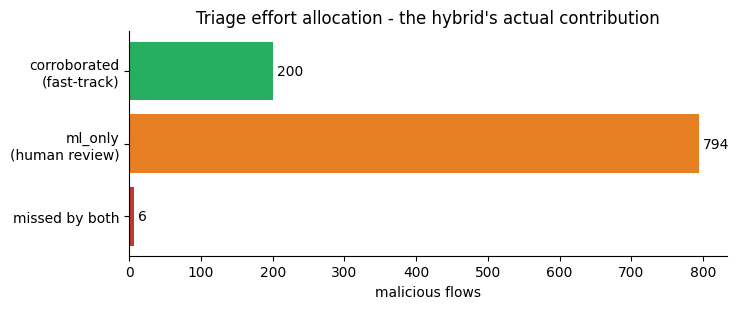

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7.5, 3.2))
labels = ["corroborated\n(fast-track)", "ml_only\n(human review)", "missed by both"]
vals = [rc["both"], rc["ml_only"], rc["missed_by_both"]]
bars = ax.barh(labels, vals, color=["#27ae60", "#e67e22", "#c0392b"])
ax.bar_label(bars, padding=3)
ax.set_xlabel("malicious flows")
ax.set_title("Triage effort allocation - the hybrid's actual contribution")
ax.spines[["top","right"]].set_visible(False); ax.invert_yaxis()
plt.tight_layout(); plt.show()


---
## 6. Decision log

Every direction change, the evidence that forced it, and what it superseded. The full narrative
version is in [`docs/plan-changelog.md`](../docs/plan-changelog.md); the method and its failures
are in [`docs/feasibility-study.md`](../docs/feasibility-study.md).

| # | Decision | Evidence | Superseded |
|---|---|---|---|
| Q1 | Dataset = corrected CSE-CIC-IDS2018 | Published errors (WTMC 2021, CNS 2022) | PRD's CICIDS2017 |
| Q18 | Attempted attacks are **malicious**, flagged | 100% of FTP-BruteForce is attempted; excluding them deletes the class | - |
| Q19 | **Port Scan** split out as an 8th class | 99.6% of "Infiltration" is NMAP Portscan | 7-class plan |
| Q20 | Disjoint train (250,655) + demo (5,000) samples | Old 1,000-row 50/50 was 15x more attack-dense than reality | Single sample |
| - | Retrain to 8 classes | Old model could not emit Infiltration (8.3% of demo data) | 6-class model |
| - | Port-shortcut hypothesis **rejected** | Ablation costs only -0.0011 macro F1 | - |
| - | F5 "zero co-occurrence" **withdrawn** | Agreement occurs 200 times after retuning | Notebook 01 |
| - | F8 "complementary coverage" **withdrawn** | signature_only = 0 | Notebook 02/03 |
| Q21(b) | Retuning tested for complementarity - **closed** | Precision 1.000, recall 20%, but signature_only still 0 | - |
| Q21(a) | Signature layer repositioned as the **trust/explainability** half | 200 corroborated vs 794 model-only alerts | "hybrid = more coverage" |

### What still carries risk

- **0.99 F1 is a testbed artefact.** Single-tool attack generation gives each class a constant
  fingerprint. Do not present it as a real-world capability claim.
- **Infiltration has 277 training and 55 held-out examples.** Its 0.906 F1 rests on a very small
  sample.
- **Five rules have hard precision ceilings** (DoS and Botnet at 0.000) and are retired rather
  than tuned.
- **6 malicious flows are missed by both detectors** - small, but the honest residual.
- Rule thresholds were tuned on the demo sample; a clean re-test on a held-out slice is still
  outstanding.